In [1]:
!pip3 install numpy matplotlib control

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control

In [5]:
# ---------------------------------------------------------
# 1. System Definition
# ---------------------------------------------------------

# Define the numerator and denominator coefficients of the transfer function:
# G(s) = (s + 1) / (s^4 + 4s^3 + 7s^2 + 6s + 3)

num = [1, 1]
den = [1, 4, 7, 6, 3]

# Create the transfer function object
sys = control.TransferFunction(num, den)

print("System Transfer Function G(s):")
print(sys)


System Transfer Function G(s):
<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              s + 1
  -----------------------------
  s^4 + 4 s^3 + 7 s^2 + 6 s + 3


In [6]:
# ---------------------------------------------------------
# 2. Performance Metrics Calculation
# ---------------------------------------------------------

# Calculate step response characteristics
info = control.step_info(sys)

print("\n--- Performance Metrics ---")
for key, value in info.items():
    print(f"{key}: {value:.4f}")


--- Performance Metrics ---
RiseTime: 1.4737
SettlingTime: 8.5656
SettlingMin: 0.3069
SettlingMax: 0.4141
Overshoot: 24.2231
Undershoot: 0.0000
Peak: 0.4141
PeakTime: 3.5920
SteadyStateValue: 0.3333


In [8]:
# ---------------------------------------------------------
# 3. Transient Analysis (Step Response)
# ---------------------------------------------------------

# Compute the step response
t, y = control.step_response(sys)

# ---------------------------------------------------------
# 4. Frequency Response (Bode Analysis)
# ---------------------------------------------------------

# Calculate Bode magnitude and phase data
mag, phase, omega = control.bode_plot(sys, plot=False)

# ---------------------------------------------------------
# 5. Visualization/Plotting
# ---------------------------------------------------------

# Create a figure with a grid layout for multiple plots
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

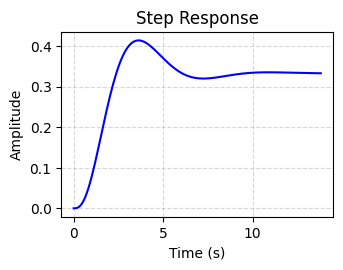

In [13]:
# --- Plot 1: Step Response ---
plt.subplot(2, 2, 1)
plt.plot(t, y, 'b', linewidth=1.5)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

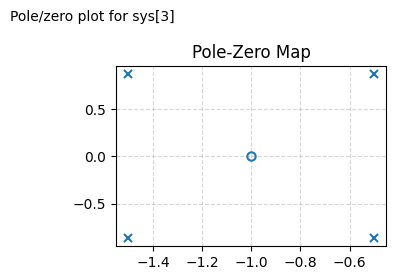

In [14]:
# --- Plot 2: Pole-Zero Map ---
plt.subplot(2, 2, 2)
control.pole_zero_plot(sys)
plt.title('Pole-Zero Map')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

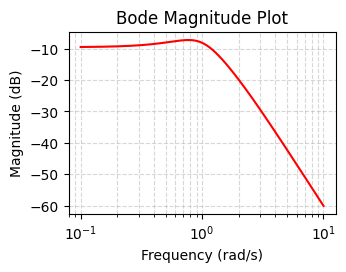

In [15]:
# --- Plot 3: Bode Magnitude ---
plt.subplot(2, 2, 3)
plt.semilogx(omega, 20 * np.log10(mag), 'r')
plt.title('Bode Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

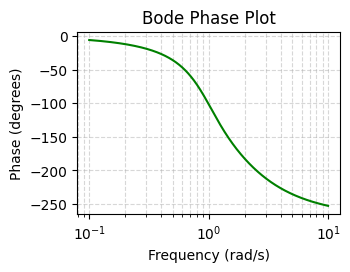

In [17]:
# --- Plot 4: Bode Phase ---
plt.subplot(2, 2, 4)
plt.semilogx(omega, np.rad2deg(phase), 'g')
plt.title('Bode Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()